# speed_cpus (Intel) vs master Clang vs GPUs — CLX + SPR + GPUs at 100K / 1M / 10M

**Sources**
- Subdir runs in `results/2026_05_17_speed_cpus/AA|DNA_<len>_<queue>_seed1_*`: Intel speed_cpus on CLX (`-nt 47`) and SPR (`-nt 103`), 100K & 1M.
- Flat-file logs in `results/2026_05_17_speed_cpus/` (added 2026-05-17):
  - `output_intel_compiler_test_DNA_*OMP_104*10000000*.log` -> SPR 103T Intel speed_cpus, DNA 10M
  - `output_10M_DNA_*OPENACC*H200*10000000*.log` -> H200 (NVHPC OpenACC), DNA 10M
- Master Clang sweep from `2026_05_10_master_cputests/all_results.csv`:
  - CLX (`CLANG_MASTER`) 48T only (single thread count kept for context)
  - SPR (`NORMALSR_MASTER`) 1T / 10T / 48T / 104T
- GPUs at 100K / 1M from `2026_05_10_master_cputests/cpu_vs_gpu_combined.csv` (A100 / H200 / V100); H200 also at 10M (DNA).

10M only has DNA, with one CPU config (SPR 103T speed) and one GPU (H200).


In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NEW_ROOT   = '/Users/u7826985/Projects/Nvidia/results/2026_05_17_speed_cpus'
MASTER_CSV = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_10_master_cputests/all_results.csv'
GPU_CSV    = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_10_master_cputests/cpu_vs_gpu_combined.csv'
OUT_DIR    = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_17_speed_cpus'
os.makedirs(OUT_DIR, exist_ok=True)

LENGTH_LABEL = {100000: '100K', 1000000: '1M', 10000000: '10M'}
LENGTHS      = [100000, 1000000, 10000000]
LEN_ORDER    = ['100K','1M','10M']
FOOTNOTE = ('CLX = Cascade Lake Xeon 8274 (NCI `normal`, 48c)   |   '
            'SPR = Sapphire Rapids Xeon 8470Q (NCI `normalsr`, 104c).   '
            'speed_cpus = Intel build (CLX -nt 47, SPR -nt 103).   master = Clang build.   '
            'H200 10M uses NVHPC OpenACC build.')

def add_footnote(fig):
    fig.text(0.5, -0.02, FOOTNOTE, ha='center', va='top', fontsize=8, style='italic', color='#444')


## 1. Parse speed_cpus logs (subdirs + flat 10M Intel log)


In [2]:
DIR_RE = re.compile(r'^(?P<dt>AA|DNA)_(?P<len>\d+[km])_(?P<queue>normal|spr)_seed(?P<seed>\d+)_(?P<job>\d+)$', re.I)
LEN_MAP = {'100k': 100000, '1m': 1000000}
QUEUE_TO_HW = {'normal': 'CLX', 'spr': 'SPR'}

def grab(content, pattern, cast=float):
    m = re.search(pattern, content)
    return cast(m.group(1)) if m else None

def parse_iqtree_log(path):
    with open(path) as f:
        c = f.read()
    rec = {
        'wall_total_sec':      grab(c, r'Total wall-clock time used:\s+([\d.]+)\s+sec'),
        'cpu_total_sec':       grab(c, r'Total CPU time used:\s+([\d.]+)\s+sec'),
        'wall_treesearch_sec': grab(c, r'Wall-clock time used for tree search:\s+([\d.]+)\s+sec'),
        'cpu_treesearch_sec':  grab(c, r'CPU time used for tree search:\s+([\d.]+)\s+sec'),
        'best_lnl':            grab(c, r'BEST SCORE FOUND\s*:\s*([-\d.]+)'),
        'iterations':          grab(c, r'Total number of iterations:\s+(\d+)', int),
        'energy_cpu_J':        grab(c, r'CPU:\s+([\d.]+)\s+J'),
        'energy_cpu_avg_W':    grab(c, r'CPU:\s+[\d.]+\s+J\s+\(avg\s+([\d.]+)\s+W\)'),
    }
    mt = re.search(r'(\d+)\s+threads\s+\((\d+)\s+CPU cores detected\)', c[:4000])
    rec['threads']        = int(mt.group(1)) if mt else None
    rec['cores_detected'] = int(mt.group(2)) if mt else None
    return rec

rows = []
for d in sorted(os.listdir(NEW_ROOT)):
    m = DIR_RE.match(d)
    if not m:
        continue
    log = os.path.join(NEW_ROOT, d, 'iqtree_run.log')
    if not os.path.isfile(log):
        rows.append({'dir': d, 'data_type': m['dt'], 'length': LEN_MAP[m['len'].lower()],
                     'hw': QUEUE_TO_HW[m['queue'].lower()], 'job': m['job'], 'completed': False})
        continue
    rec = parse_iqtree_log(log)
    rec.update({'dir': d, 'data_type': m['dt'], 'length': LEN_MAP[m['len'].lower()],
                'hw': QUEUE_TO_HW[m['queue'].lower()], 'job': m['job'],
                'completed': rec['wall_total_sec'] is not None})
    rows.append(rec)

new_df = pd.DataFrame(rows)
new_df['length_label']        = new_df['length'].map(LENGTH_LABEL)
new_df['build']               = 'speed_cpus (Intel)'
new_df['wall_total_min']      = new_df['wall_total_sec']      / 60
new_df['wall_treesearch_min'] = new_df['wall_treesearch_sec'] / 60
new_df = (new_df.sort_values('job').groupby(['data_type', 'length', 'hw'], as_index=False).tail(1)
                .sort_values(['data_type', 'length', 'hw']).reset_index(drop=True))

# flat-file 10M Intel SPR speed (DNA only)
for log in glob.glob(os.path.join(NEW_ROOT, 'output_intel_compiler_test_DNA_*10000000*.log')):
    rec = parse_iqtree_log(log)
    rec.update({'dir': os.path.basename(log), 'data_type':'DNA','length':10000000,
                'length_label':'10M','hw':'SPR','job':'flat','build':'speed_cpus (Intel)',
                'wall_total_min':      rec['wall_total_sec']/60 if rec['wall_total_sec'] else None,
                'wall_treesearch_min': rec['wall_treesearch_sec']/60 if rec['wall_treesearch_sec'] else None,
                'completed': rec['wall_total_sec'] is not None})
    new_df = pd.concat([new_df, pd.DataFrame([rec])], ignore_index=True)

new_df.to_csv(os.path.join(OUT_DIR, 'speed_cpus_runs.csv'), index=False)
speed_cpus = new_df[new_df['completed']].copy()
speed_cpus['config_label'] = speed_cpus['hw'] + ' ' + speed_cpus['threads'].astype(int).astype(str) + 'T (speed)'
speed_cpus[['dir','data_type','length_label','hw','threads','wall_total_min','wall_treesearch_min','best_lnl','energy_cpu_J','energy_cpu_avg_W']]


,dir,data_type,length_label,hw,threads,wall_total_min,wall_treesearch_min,best_lnl,energy_cpu_J,energy_cpu_avg_W
0,AA_100k_normal_seed1_168422809,AA,100K,CLX,47.0,57.680217,38.956117,-7.541977e+06,555794.454,160.546
1,AA_100k_spr_seed1_168425673,AA,100K,SPR,103.0,19.492600,12.741300,-7.541977e+06,262981.678,224.662
2,AA_1m_normal_seed1_168425490,AA,1M,CLX,47.0,855.470867,580.366217,-7.860520e+07,492588.474,9.595
3,AA_1m_spr_seed1_168425491,AA,1M,SPR,103.0,379.603767,251.643417,-7.860520e+07,202325.190,8.880
4,DNA_100k_normal_seed1_168422811,DNA,100K,CLX,47.0,9.100733,6.413967,-5.692985e+06,213674.721,390.593
5,DNA_100k_spr_seed1_168425674,DNA,100K,SPR,103.0,4.818683,3.774117,-5.692985e+06,180642.892,622.542
6,DNA_1m_normal_seed1_168422813,DNA,1M,CLX,47.0,295.880967,124.698067,-5.920802e+07,505373.194,28.455
7,DNA_1m_spr_seed1_168425675,DNA,1M,SPR,103.0,101.907500,43.283250,-5.920802e+07,394337.724,64.415
8,output_intel_compiler_test_DNA_GTR+I+G4_OMP_10...,DNA,10M,SPR,103.0,2387.948867,1140.080833,-5.789538e+08,314564.937,2.194


## 2. Master Clang baseline — keep CLX 48T + SPR 1/10/48/104T (100K & 1M)


In [3]:
master = pd.read_csv(MASTER_CSV)
master = master[master['length'].isin([100000, 1000000])].copy()
master['hw'] = master['system'].map({'CLANG_MASTER':'CLX','NORMALSR_MASTER':'SPR'})
master = master[((master['hw']=='SPR')) | ((master['hw']=='CLX') & (master['threads']==48))]
master['build'] = 'master (Clang)'
master['config_label'] = master['hw'] + ' ' + master['threads'].astype(str) + 'T'
master_cpu = master[['data_type','length','length_label','hw','threads','build','config_label',
                     'wall_total_sec','cpu_total_sec','wall_treesearch_sec','cpu_treesearch_sec',
                     'wall_total_min','wall_treesearch_min','best_lnl','iterations','completed']]
master_cpu = master_cpu[master_cpu['completed']].sort_values(['data_type','length','hw','threads']).reset_index(drop=True)
master_cpu


,data_type,length,length_label,hw,threads,build,config_label,wall_total_sec,cpu_total_sec,wall_treesearch_sec,cpu_treesearch_sec,wall_total_min,wall_treesearch_min,best_lnl,iterations,completed
0,AA,100000,100K,CLX,48,master (Clang),CLX 48T,3302.703,141282.452,2350.151,97496.008,55.045050,39.169183,-7.541977e+06,102.0,True
1,AA,100000,100K,SPR,1,master (Clang),SPR 1T,45937.763,45593.500,28626.104,28515.266,765.629383,477.101733,-7.541977e+06,102.0,True
2,AA,100000,100K,SPR,10,master (Clang),SPR 10T,8348.746,81593.611,5603.428,54516.055,139.145767,93.390467,-7.541977e+06,102.0,True
3,AA,100000,100K,SPR,48,master (Clang),SPR 48T,2246.251,98954.798,1538.639,66760.426,37.437517,25.643983,-7.541977e+06,102.0,True
4,AA,100000,100K,SPR,104,master (Clang),SPR 104T,1424.306,129068.968,1026.614,91637.187,23.738433,17.110233,-7.541977e+06,102.0,True
5,AA,1000000,1M,CLX,48,master (Clang),CLX 48T,48694.865,1827015.982,35386.297,1247625.066,811.581083,589.771617,-7.860520e+07,102.0,True
6,AA,1000000,1M,SPR,10,master (Clang),SPR 10T,92611.276,862570.183,59202.886,559858.115,1543.521267,986.714767,-7.860520e+07,102.0,True
7,AA,1000000,1M,SPR,48,master (Clang),SPR 48T,36825.726,1571492.311,25537.946,1074174.984,613.762100,425.632433,-7.860520e+07,102.0,True
8,AA,1000000,1M,SPR,104,master (Clang),SPR 104T,29235.971,2625074.204,22002.277,1946854.554,487.266183,366.704617,-7.860520e+07,102.0,True
9,DNA,100000,100K,CLX,48,master (Clang),CLX 48T,639.938,26998.253,500.806,20740.125,10.665633,8.346767,-5.692985e+06,102.0,True


## 3. GPU rows (A100 / H200 / V100; H200 at 10M)


In [4]:
cvg = pd.read_csv(GPU_CSV)
gpu = cvg[(cvg['kind']=='GPU') & (cvg['length'].isin([100000,1000000])) & cvg['completed']].copy()
gpu['hw'] = gpu['hardware'].str.replace('GPU_','', regex=False)
gpu['threads'] = 1
gpu['build'] = 'GPU'
gpu['config_label'] = 'GPU ' + gpu['hw']
gpu['cpu_treesearch_sec'] = np.nan
gpu = gpu[['data_type','length','length_label','hw','threads','build','config_label',
           'wall_total_sec','cpu_total_sec','wall_treesearch_sec','cpu_treesearch_sec',
           'wall_total_min','wall_treesearch_min','best_lnl','iterations']]

for log in glob.glob(os.path.join(NEW_ROOT, 'output_10M_DNA_*H200*10000000*.log')):
    rec = parse_iqtree_log(log)
    gpu = pd.concat([gpu, pd.DataFrame([{
        'data_type':'DNA','length':10000000,'length_label':'10M','hw':'H200','threads':1,
        'build':'GPU','config_label':'GPU H200',
        'wall_total_sec':rec['wall_total_sec'],'cpu_total_sec':rec['cpu_total_sec'],
        'wall_treesearch_sec':rec['wall_treesearch_sec'],'cpu_treesearch_sec':np.nan,
        'wall_total_min':rec['wall_total_sec']/60,
        'wall_treesearch_min':rec['wall_treesearch_sec']/60,
        'best_lnl':rec['best_lnl'],'iterations':rec['iterations'],
    }])], ignore_index=True)

gpu = gpu.sort_values(['data_type','length','hw']).reset_index(drop=True)
gpu


,data_type,length,length_label,hw,threads,build,config_label,wall_total_sec,cpu_total_sec,wall_treesearch_sec,cpu_treesearch_sec,wall_total_min,wall_treesearch_min,best_lnl,iterations
0,AA,100000,100K,A100,1,GPU,GPU A100,2272.027,2209.026,1644.446,NaN,37.867117,27.407433,-7.541977e+06,102.0
1,AA,100000,100K,H200,1,GPU,GPU H200,1367.078,1353.725,991.076,NaN,22.784633,16.517933,-7.541977e+06,102.0
2,AA,100000,100K,V100,1,GPU,GPU V100,2905.543,2723.170,2065.578,NaN,48.425717,34.426300,-7.541977e+06,102.0
3,AA,1000000,1M,H200,1,GPU,GPU H200,12197.809,12021.657,8698.133,NaN,203.296817,144.968883,-7.860520e+07,102.0
4,DNA,100000,100K,A100,1,GPU,GPU A100,958.752,813.285,540.329,NaN,15.979200,9.005483,-5.692985e+06,102.0
5,DNA,100000,100K,H200,1,GPU,GPU H200,516.057,509.792,298.090,NaN,8.600950,4.968167,-5.692985e+06,102.0
6,DNA,100000,100K,V100,1,GPU,GPU V100,1000.451,990.662,581.892,NaN,16.674183,9.698200,-5.692985e+06,102.0
7,DNA,1000000,1M,A100,1,GPU,GPU A100,4523.878,3837.279,2472.475,NaN,75.397967,41.207917,-5.920802e+07,102.0
8,DNA,1000000,1M,H200,1,GPU,GPU H200,2673.447,2605.771,1571.067,NaN,44.557450,26.184450,-5.920802e+07,102.0
9,DNA,1000000,1M,V100,1,GPU,GPU V100,6975.073,6864.801,4102.941,NaN,116.251217,68.382350,-5.920802e+07,102.0


## 4. Combined long table


In [5]:
common = ['data_type','length','length_label','hw','threads','build','config_label',
          'wall_total_sec','wall_treesearch_sec','wall_total_min','wall_treesearch_min',
          'best_lnl','iterations']
combined = pd.concat([master_cpu[common], speed_cpus[common], gpu[common]], ignore_index=True)
combined.to_csv(os.path.join(OUT_DIR, 'combined_runs.csv'), index=False)

pivot_wall = combined.pivot_table(index=['data_type','length_label'], columns='config_label',
                                  values='wall_total_min', aggfunc='first')
pivot_wall.to_csv(os.path.join(OUT_DIR, 'wall_total_min_pivot.csv'))
pivot_wall.round(1)


config_label            CLX 47T (speed)  CLX 48T  GPU A100  GPU H200  \
data_type length_label                                                 
AA        100K                     57.7     55.0      37.9      22.8   
          1M                      855.5    811.6       NaN     203.3   
DNA       100K                      9.1     10.7      16.0       8.6   
          10M                       NaN      NaN       NaN     840.3   
          1M                      295.9    219.8      75.4      44.6   

config_label            GPU V100  SPR 103T (speed)  SPR 104T  SPR 10T  SPR 1T  \
data_type length_label                                                          
AA        100K              48.4              19.5      23.7    139.1   765.6   
          1M                 NaN             379.6     487.3   1543.5     NaN   
DNA       100K              16.7               4.8       8.6     22.2   198.1   
          10M                NaN            2387.9       NaN      NaN     NaN   
          1M               116.3             101.9      83.5    482.0  2137.0   

config_label            SPR 48T  
data_type length_label           
AA        100K             37.4  
          1M              613.8  
DNA       100K             10.1  
          10M               NaN  
          1M              147.5

In [6]:
pivot_ts = combined.pivot_table(index=['data_type','length_label'], columns='config_label',
                                values='wall_treesearch_min', aggfunc='first')
pivot_ts.to_csv(os.path.join(OUT_DIR, 'wall_treesearch_min_pivot.csv'))
pivot_ts.round(1)


config_label            CLX 47T (speed)  CLX 48T  GPU A100  GPU H200  \
data_type length_label                                                 
AA        100K                     39.0     39.2      27.4      16.5   
          1M                      580.4    589.8       NaN     145.0   
DNA       100K                      6.4      8.3       9.0       5.0   
          10M                       NaN      NaN       NaN     435.3   
          1M                      124.7    118.8      41.2      26.2   

config_label            GPU V100  SPR 103T (speed)  SPR 104T  SPR 10T  SPR 1T  \
data_type length_label                                                          
AA        100K              34.4              12.7      17.1     93.4   477.1   
          1M                 NaN             251.6     366.7    986.7     NaN   
DNA       100K               9.7               3.8       6.8     15.4   127.1   
          10M                NaN            1140.1       NaN      NaN     NaN   
          1M                68.4              43.3      50.1    232.5   899.2   

config_label            SPR 48T  
data_type length_label           
AA        100K             25.6  
          1M              425.6  
DNA       100K              7.3  
          10M               NaN  
          1M               82.5

## 5. Plots
### 5.1 Wall-clock and tree-search time: CLX + SPR + GPUs at 100K / 1M / 10M


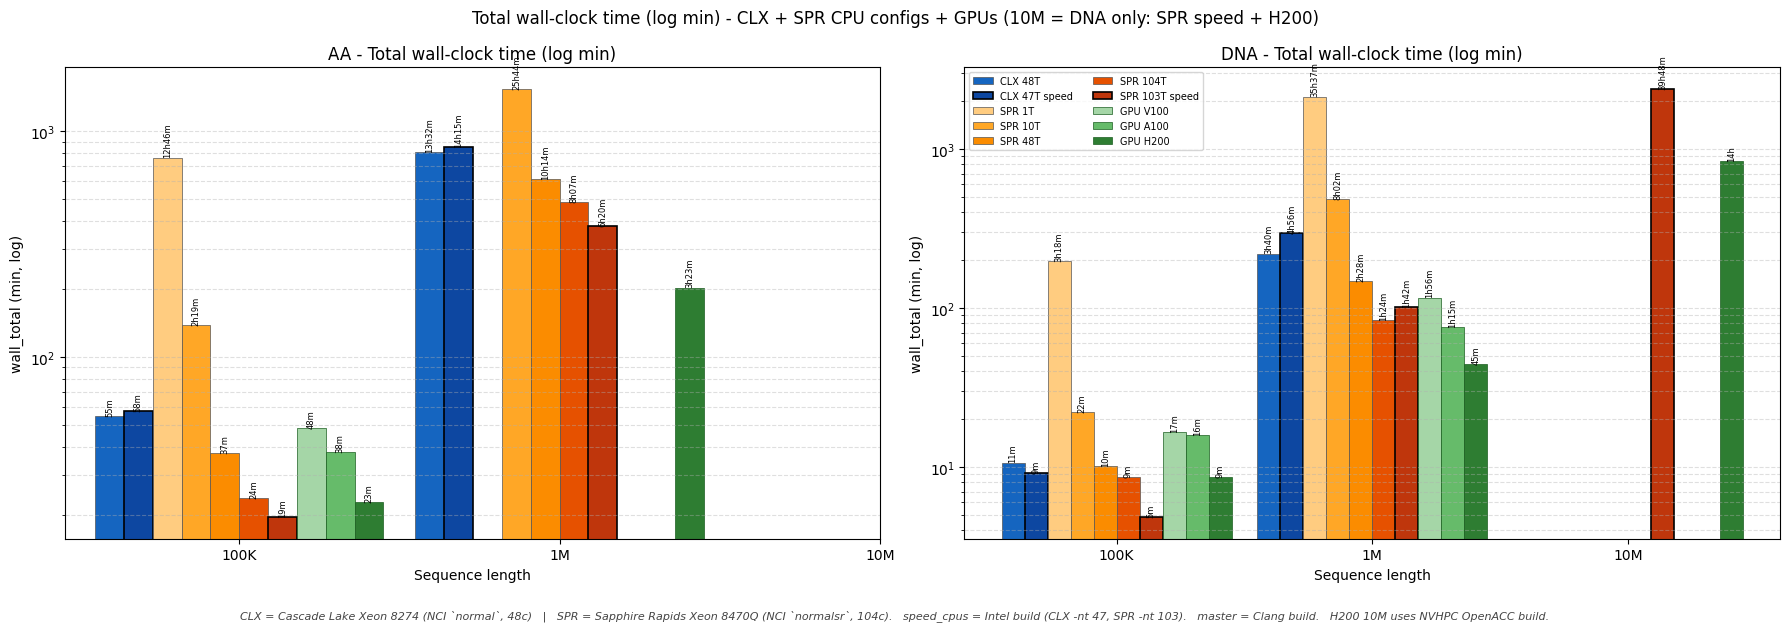

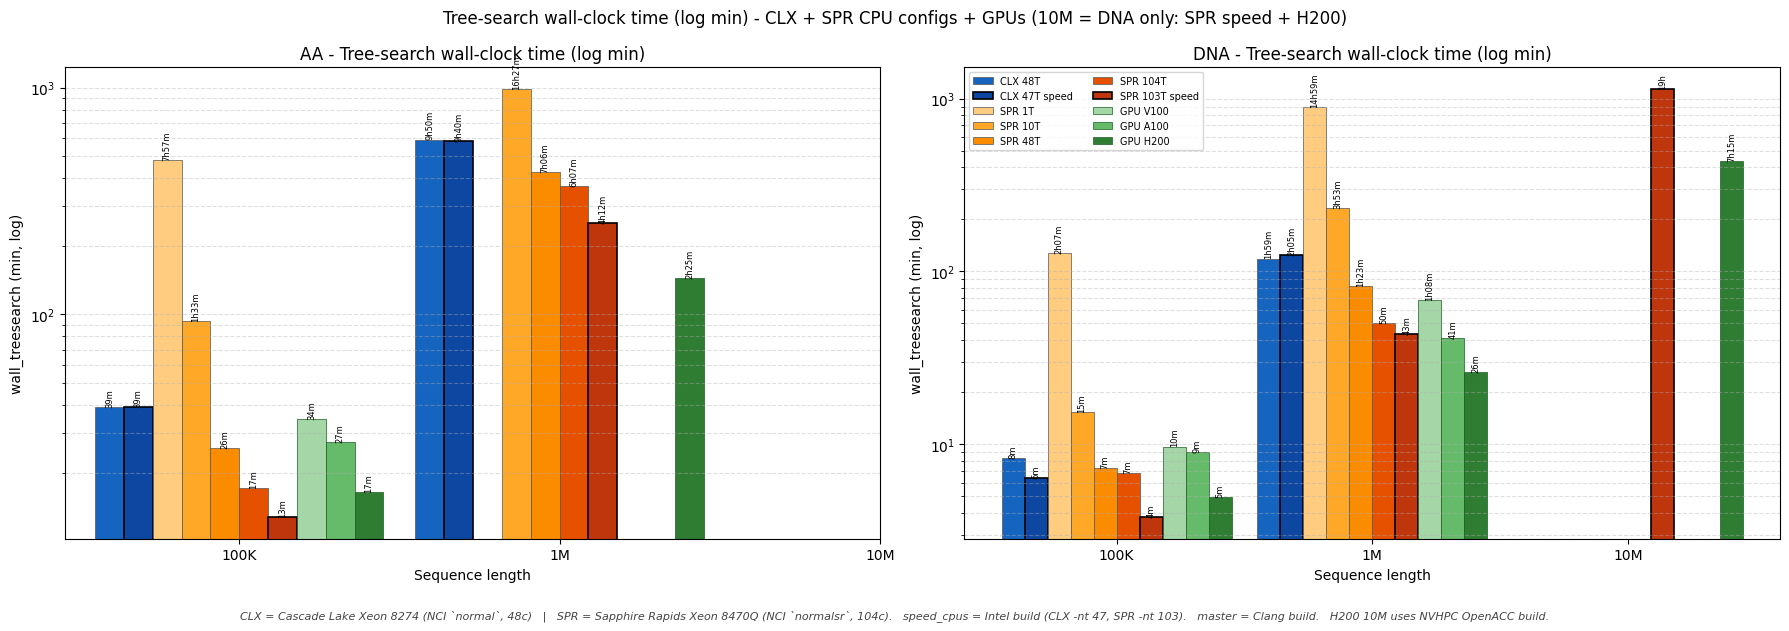

In [7]:
def fmt_min(m):
    if pd.isna(m): return ''
    if m < 1: return f'{m*60:.0f}s'
    if m < 60: return f'{m:.0f}m'
    h, mm = divmod(int(round(m)), 60)
    return f'{h}h{mm:02d}m' if mm else f'{h}h'

CONFIG_ORDER = [
    ('CLX 48T',         'CLX 48T',          '#1565C0', '#555'),
    ('CLX 47T speed',   'CLX 47T (speed)',  '#0D47A1', '#000'),
    ('SPR 1T',          'SPR 1T',           '#FFCC80', '#555'),
    ('SPR 10T',         'SPR 10T',          '#FFA726', '#555'),
    ('SPR 48T',         'SPR 48T',          '#FB8C00', '#555'),
    ('SPR 104T',        'SPR 104T',         '#E65100', '#555'),
    ('SPR 103T speed',  'SPR 103T (speed)', '#BF360C', '#000'),
    ('GPU V100',        'GPU V100',         '#A5D6A7', '#1B5E20'),
    ('GPU A100',        'GPU A100',         '#66BB6A', '#1B5E20'),
    ('GPU H200',        'GPU H200',         '#2E7D32', '#1B5E20'),
]

def get_val(dt, length, config_label, col):
    r = combined[(combined['data_type']==dt) & (combined['length']==length) & (combined['config_label']==config_label)]
    return r[col].iloc[0] if len(r) and pd.notna(r[col].iloc[0]) else np.nan

def bars(metric_col, title, ylabel, fname):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    n = len(CONFIG_ORDER)
    x = np.arange(len(LENGTHS))
    width = 0.9 / n
    for ax, dt in zip(axes, ['AA', 'DNA']):
        for i, (label, cfg, color, edge) in enumerate(CONFIG_ORDER):
            vals = [get_val(dt, L, cfg, metric_col) for L in LENGTHS]
            offs = x + (i - n/2 + 0.5) * width
            lw = 1.2 if 'speed' in label else 0.5
            ax.bar(offs, vals, width, label=label, color=color, edgecolor=edge, linewidth=lw)
            for bx, by in zip(offs, vals):
                if not np.isnan(by):
                    ax.text(bx, by, fmt_min(by), ha='center', va='bottom', fontsize=6, rotation=90)
        ax.set_xticks(x); ax.set_xticklabels([LENGTH_LABEL[L] for L in LENGTHS])
        ax.set_xlabel('Sequence length'); ax.set_ylabel(ylabel); ax.set_yscale('log')
        ax.set_title(f'{dt} - {title}')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4, which='both')
    axes[1].legend(fontsize=7, ncol=2, loc='upper left')
    fig.suptitle(f'{title} - CLX + SPR CPU configs + GPUs (10M = DNA only: SPR speed + H200)')
    fig.tight_layout(); add_footnote(fig)
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()

bars('wall_total_min',      'Total wall-clock time (log min)',       'wall_total (min, log)',      'fig01_wall_total.png')
bars('wall_treesearch_min', 'Tree-search wall-clock time (log min)', 'wall_treesearch (min, log)', 'fig02_wall_treesearch.png')


### 5.2 Speedup of speed_cpus over same-hardware master Clang peer (CLX 47T vs CLX 48T; SPR 103T vs SPR 104T)


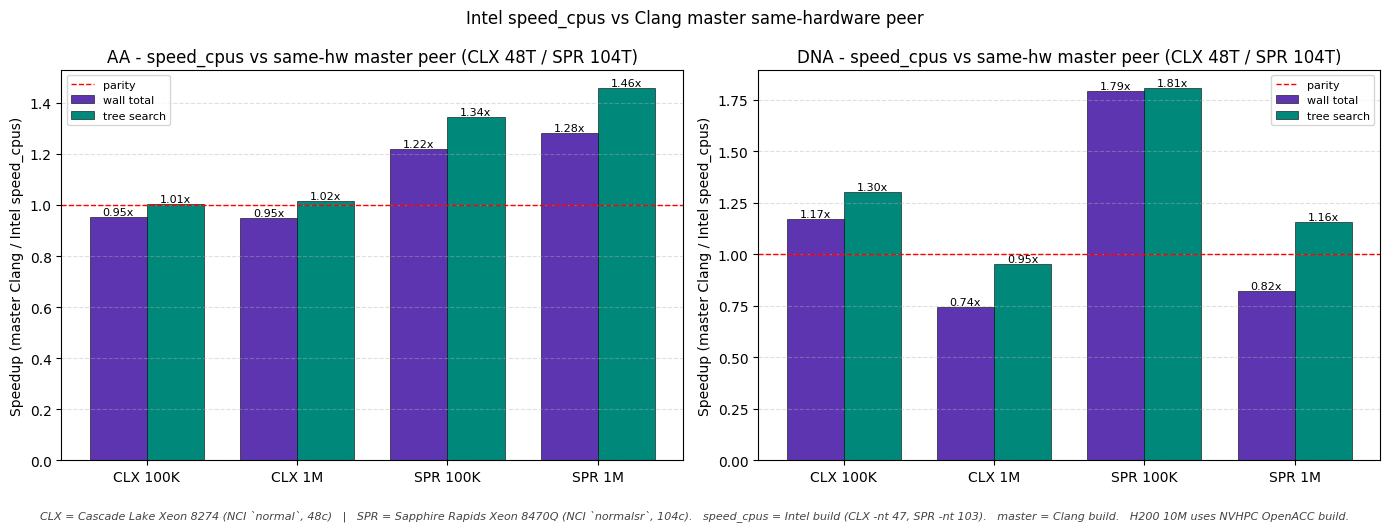

,data_type,length_label,hw,new_threads,new_wall_min,new_ts_min,master_threads,master_wall_min,master_ts_min,speedup_wall,speedup_ts
0,AA,100K,CLX,47.0,57.680,38.956,48,55.045,39.169,0.954,1.005
1,AA,1M,CLX,47.0,855.471,580.366,48,811.581,589.772,0.949,1.016
2,AA,100K,SPR,103.0,19.493,12.741,104,23.738,17.110,1.218,1.343
3,AA,1M,SPR,103.0,379.604,251.643,104,487.266,366.705,1.284,1.457
4,DNA,100K,CLX,47.0,9.101,6.414,48,10.666,8.347,1.172,1.301
5,DNA,1M,CLX,47.0,295.881,124.698,48,219.827,118.755,0.743,0.952
6,DNA,100K,SPR,103.0,4.819,3.774,104,8.642,6.813,1.794,1.805
7,DNA,1M,SPR,103.0,101.908,43.283,104,83.535,50.080,0.820,1.157


In [8]:
PEER_THREADS = {'CLX': 48, 'SPR': 104}
rows = []
for _, r in speed_cpus.iterrows():
    pt = PEER_THREADS.get(r['hw'])
    if pt is None:
        continue
    peer = master_cpu[(master_cpu['data_type']==r['data_type']) & (master_cpu['length']==r['length']) &
                      (master_cpu['hw']==r['hw']) & (master_cpu['threads']==pt)]
    if not len(peer):
        continue
    pr = peer.iloc[0]
    rows.append({
        'data_type': r['data_type'], 'length_label': r['length_label'], 'hw': r['hw'],
        'new_threads': r['threads'], 'new_wall_min': r['wall_total_min'], 'new_ts_min': r['wall_treesearch_min'],
        'master_threads': pt, 'master_wall_min': pr['wall_total_min'], 'master_ts_min': pr['wall_treesearch_min'],
        'speedup_wall': pr['wall_total_sec']/r['wall_total_sec'],
        'speedup_ts':   pr['wall_treesearch_sec']/r['wall_treesearch_sec'],
    })
speedup_df = pd.DataFrame(rows)
speedup_df['length_label'] = pd.Categorical(speedup_df['length_label'], categories=LEN_ORDER, ordered=True)
speedup_df = speedup_df.sort_values(['data_type','hw','length_label']).reset_index(drop=True)
speedup_df.to_csv(os.path.join(OUT_DIR, 'speedup_vs_master.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dt in zip(axes, ['AA','DNA']):
    sub = speedup_df[speedup_df['data_type']==dt].copy()
    sub['x'] = sub['hw'] + ' ' + sub['length_label'].astype(str)
    x = np.arange(len(sub))
    w = 0.38
    bw = ax.bar(x - w/2, sub['speedup_wall'], w, label='wall total', color='#5E35B1', edgecolor='black', linewidth=0.4)
    bt = ax.bar(x + w/2, sub['speedup_ts'],   w, label='tree search', color='#00897B', edgecolor='black', linewidth=0.4)
    for bars_ in (bw, bt):
        for rect in bars_:
            h = rect.get_height()
            if pd.notna(h):
                ax.text(rect.get_x()+rect.get_width()/2, h, f'{h:.2f}x', ha='center', va='bottom', fontsize=8)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='parity')
    ax.set_xticks(x); ax.set_xticklabels(sub['x'].tolist())
    ax.set_ylabel('Speedup (master Clang / Intel speed_cpus)')
    ax.set_title(f'{dt} - speed_cpus vs same-hw master peer (CLX 48T / SPR 104T)')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4); ax.legend(fontsize=8)
fig.suptitle('Intel speed_cpus vs Clang master same-hardware peer')
fig.tight_layout(); add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig03_speedup_vs_master.png'), dpi=150, bbox_inches='tight')
plt.show()
speedup_df.round(3)


### 5.3 GPU speedup over best CPU available at each cell (SPR speed_cpus where available, else CLX speed_cpus)

GPUs are compared to the fastest Intel speed_cpus run on the same `(data_type, length)`: SPR 103T when present, otherwise CLX 47T.


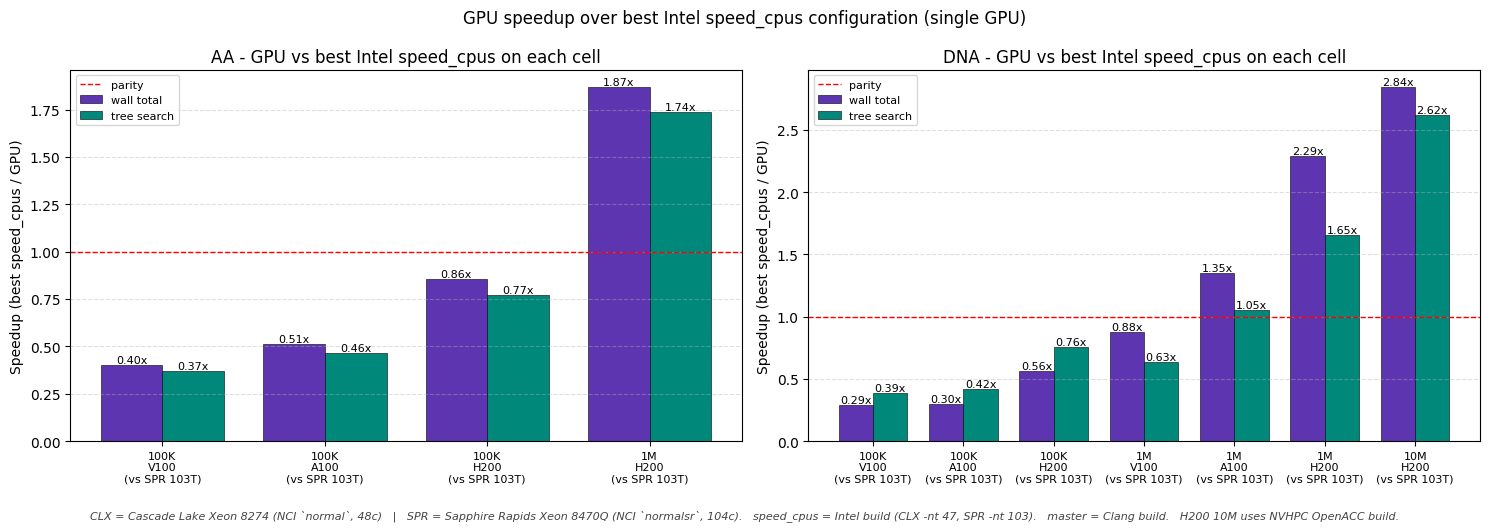

,data_type,length_label,gpu,gpu_wall_min,gpu_ts_min,cpu_ref,cpu_wall_min,cpu_ts_min,speedup_wall,speedup_ts,gpu_lnl,cpu_lnl
0,AA,100K,A100,37.867,27.407,SPR 103T speed,19.493,12.741,0.515,0.465,-7.541977e+06,-7.541977e+06
1,AA,100K,H200,22.785,16.518,SPR 103T speed,19.493,12.741,0.856,0.771,-7.541977e+06,-7.541977e+06
2,AA,100K,V100,48.426,34.426,SPR 103T speed,19.493,12.741,0.403,0.370,-7.541977e+06,-7.541977e+06
3,AA,1M,H200,203.297,144.969,SPR 103T speed,379.604,251.643,1.867,1.736,-7.860520e+07,-7.860520e+07
4,DNA,100K,A100,15.979,9.005,SPR 103T speed,4.819,3.774,0.302,0.419,-5.692985e+06,-5.692985e+06
5,DNA,100K,H200,8.601,4.968,SPR 103T speed,4.819,3.774,0.560,0.760,-5.692985e+06,-5.692985e+06
6,DNA,100K,V100,16.674,9.698,SPR 103T speed,4.819,3.774,0.289,0.389,-5.692985e+06,-5.692985e+06
7,DNA,1M,A100,75.398,41.208,SPR 103T speed,101.908,43.283,1.352,1.050,-5.920802e+07,-5.920802e+07
8,DNA,1M,H200,44.557,26.184,SPR 103T speed,101.908,43.283,2.287,1.653,-5.920802e+07,-5.920802e+07
9,DNA,1M,V100,116.251,68.382,SPR 103T speed,101.908,43.283,0.877,0.633,-5.920802e+07,-5.920802e+07


In [9]:
rows = []
for _, g in gpu.iterrows():
    cands = speed_cpus[(speed_cpus['data_type']==g['data_type']) & (speed_cpus['length']==g['length'])].sort_values('wall_total_sec')
    if not len(cands):
        continue
    c = cands.iloc[0]
    rows.append({
        'data_type': g['data_type'], 'length_label': g['length_label'], 'gpu': g['hw'],
        'gpu_wall_min': g['wall_total_min'], 'gpu_ts_min': g['wall_treesearch_min'],
        'cpu_ref': c['hw'] + ' ' + str(int(c['threads'])) + 'T speed',
        'cpu_wall_min': c['wall_total_min'], 'cpu_ts_min': c['wall_treesearch_min'],
        'speedup_wall': c['wall_total_sec'] / g['wall_total_sec'],
        'speedup_ts':   c['wall_treesearch_sec'] / g['wall_treesearch_sec'],
        'gpu_lnl': g['best_lnl'], 'cpu_lnl': c['best_lnl'],
    })
gpu_vs_speed = pd.DataFrame(rows)
gpu_vs_speed['length_label'] = pd.Categorical(gpu_vs_speed['length_label'], categories=LEN_ORDER, ordered=True)
gpu_vs_speed = gpu_vs_speed.sort_values(['data_type','length_label','gpu']).reset_index(drop=True)
gpu_vs_speed.to_csv(os.path.join(OUT_DIR, 'gpu_vs_speed_cpus.csv'), index=False)

GPU_ORDER = ['V100','A100','H200']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, dt in zip(axes, ['AA','DNA']):
    sub = gpu_vs_speed[gpu_vs_speed['data_type']==dt].copy()
    sub['gpu'] = pd.Categorical(sub['gpu'], categories=GPU_ORDER, ordered=True)
    sub = sub.sort_values(['length_label','gpu']).reset_index(drop=True)
    sub['x'] = sub['length_label'].astype(str) + '\n' + sub['gpu'].astype(str) + '\n(vs ' + sub['cpu_ref'].str.replace(' speed','') + ')'
    x = np.arange(len(sub))
    w = 0.38
    bw = ax.bar(x - w/2, sub['speedup_wall'], w, label='wall total', color='#5E35B1', edgecolor='black', linewidth=0.4)
    bt = ax.bar(x + w/2, sub['speedup_ts'],   w, label='tree search', color='#00897B', edgecolor='black', linewidth=0.4)
    for bars_ in (bw, bt):
        for rect in bars_:
            h = rect.get_height()
            if pd.notna(h):
                ax.text(rect.get_x()+rect.get_width()/2, h, f'{h:.2f}x', ha='center', va='bottom', fontsize=8)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='parity')
    ax.set_xticks(x); ax.set_xticklabels(sub['x'].tolist(), fontsize=8)
    ax.set_ylabel('Speedup (best speed_cpus / GPU)')
    ax.set_title(f'{dt} - GPU vs best Intel speed_cpus on each cell')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4); ax.legend(fontsize=8)
fig.suptitle('GPU speedup over best Intel speed_cpus configuration (single GPU)')
fig.tight_layout(); add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig04_gpu_vs_speed_cpus.png'), dpi=150, bbox_inches='tight')
plt.show()
gpu_vs_speed.round(3)


### 5.4 CPU energy for speed_cpus runs (CLX + SPR)

Reported by the IQ-TREE `Energy:` block. Long runs (1M / 10M) have implausibly low avg-W readings — RAPL counter wraps make those energy totals unreliable.


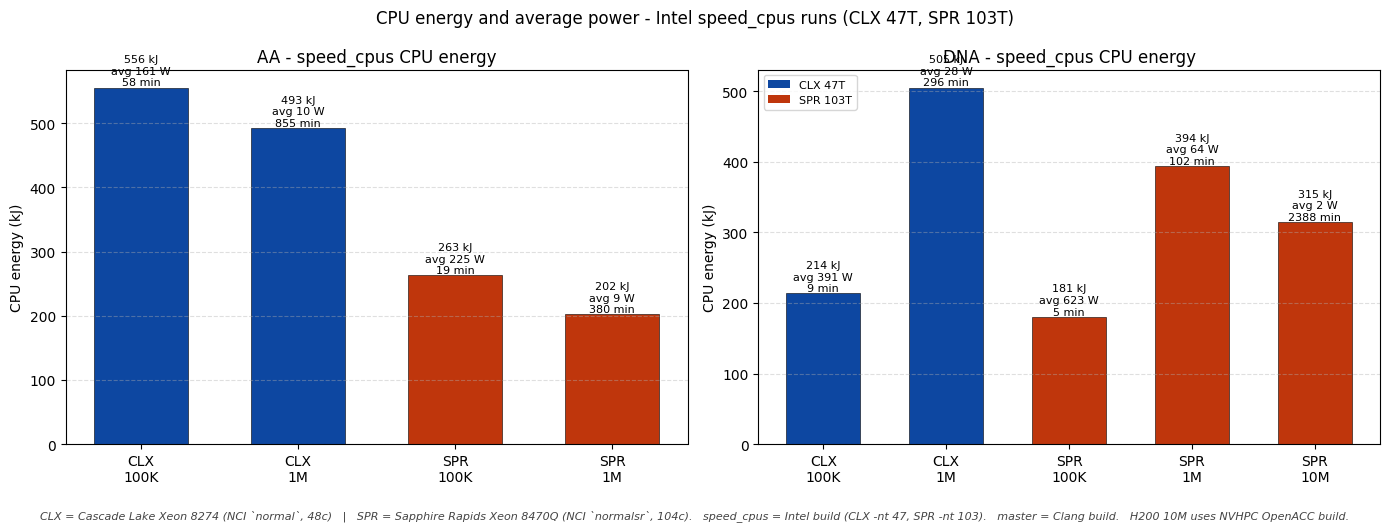

,data_type,hw,length_label,threads,wall_total_min,energy_cpu_J,energy_cpu_avg_W,energy_cpu_kJ
0,AA,CLX,100K,47.0,57.680217,555794.454,160.546,555.794454
1,AA,CLX,1M,47.0,855.470867,492588.474,9.595,492.588474
2,AA,SPR,100K,103.0,19.492600,262981.678,224.662,262.981678
3,AA,SPR,1M,103.0,379.603767,202325.190,8.880,202.325190
4,DNA,CLX,100K,47.0,9.100733,213674.721,390.593,213.674721
5,DNA,CLX,1M,47.0,295.880967,505373.194,28.455,505.373194
6,DNA,SPR,100K,103.0,4.818683,180642.892,622.542,180.642892
7,DNA,SPR,1M,103.0,101.907500,394337.724,64.415,394.337724
8,DNA,SPR,10M,103.0,2387.948867,314564.937,2.194,314.564937


In [10]:
energy = speed_cpus.copy()
energy['energy_cpu_kJ'] = energy['energy_cpu_J'] / 1000.0
energy['length_label'] = pd.Categorical(energy['length_label'], categories=LEN_ORDER, ordered=True)
energy = energy.sort_values(['data_type','hw','length_label']).reset_index(drop=True)

HW_COLOR = {'CLX': '#0D47A1', 'SPR': '#BF360C'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, dt in zip(axes, ['AA','DNA']):
    sub = energy[energy['data_type']==dt]
    x = np.arange(len(sub))
    colors = [HW_COLOR[h] for h in sub['hw']]
    b = ax.bar(x, sub['energy_cpu_kJ'], 0.6, color=colors, edgecolor='black', linewidth=0.4)
    for rect, w, mins in zip(b, sub['energy_cpu_avg_W'], sub['wall_total_min']):
        h = rect.get_height()
        if pd.isna(h):
            continue
        ax.text(rect.get_x()+rect.get_width()/2, h, f'{h:.0f} kJ\navg {w:.0f} W\n{mins:.0f} min',
                ha='center', va='bottom', fontsize=8)
    labels = [f"{r['hw']}\n{r['length_label']}" for _, r in sub.iterrows()]
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('CPU energy (kJ)')
    ax.set_title(f'{dt} - speed_cpus CPU energy')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor=HW_COLOR['CLX'], label='CLX 47T'),
                        Patch(facecolor=HW_COLOR['SPR'], label='SPR 103T')], fontsize=8, loc='upper left')
fig.suptitle('CPU energy and average power - Intel speed_cpus runs (CLX 47T, SPR 103T)')
fig.tight_layout(); add_footnote(fig)
fig.savefig(os.path.join(OUT_DIR, 'fig05_energy.png'), dpi=150, bbox_inches='tight')
plt.show()

energy[['data_type','hw','length_label','threads','wall_total_min','energy_cpu_J','energy_cpu_avg_W','energy_cpu_kJ']]


### 5.5 Log-likelihood consistency (speed_cpus CLX 47T, SPR 103T vs master 48T/104T vs GPUs)


In [11]:
rows = []
for _, r in speed_cpus.iterrows():
    base = r['best_lnl']
    pt = PEER_THREADS.get(r['hw'])
    peer = master_cpu[(master_cpu['data_type']==r['data_type']) & (master_cpu['length']==r['length']) &
                      (master_cpu['hw']==r['hw']) & (master_cpu['threads']==pt)] if pt else pd.DataFrame()
    pl = peer['best_lnl'].iloc[0] if len(peer) else np.nan
    rec = {'data_type': r['data_type'], 'length_label': r['length_label'], 'hw': r['hw'],
           'speed_cpus_lnl': base, 'master_peer_threads': pt, 'master_peer_lnl': pl,
           'diff_master_peer': (pl - base) if pd.notna(pl) else np.nan}
    for g_name in ['V100','A100','H200']:
        gr = gpu[(gpu['data_type']==r['data_type']) & (gpu['length']==r['length']) & (gpu['hw']==g_name)]
        rec[f'gpu_{g_name}_lnl']  = gr['best_lnl'].iloc[0] if len(gr) else np.nan
        rec[f'diff_gpu_{g_name}'] = (rec[f'gpu_{g_name}_lnl'] - base) if pd.notna(rec[f'gpu_{g_name}_lnl']) else np.nan
    rows.append(rec)
lnl = pd.DataFrame(rows)
lnl['length_label'] = pd.Categorical(lnl['length_label'], categories=LEN_ORDER, ordered=True)
lnl = lnl.sort_values(['data_type','hw','length_label']).reset_index(drop=True)
lnl.to_csv(os.path.join(OUT_DIR, 'lnl_consistency.csv'), index=False)
lnl


,data_type,length_label,hw,speed_cpus_lnl,master_peer_threads,master_peer_lnl,diff_master_peer,gpu_V100_lnl,diff_gpu_V100,gpu_A100_lnl,diff_gpu_A100,gpu_H200_lnl,diff_gpu_H200
0,AA,100K,CLX,-7.541977e+06,48,-7.541977e+06,0.0,-7.541977e+06,0.000,-7.541977e+06,0.002,-7.541977e+06,0.000
1,AA,1M,CLX,-7.860520e+07,48,-7.860520e+07,0.0,NaN,NaN,NaN,NaN,-7.860520e+07,0.000
2,AA,100K,SPR,-7.541977e+06,104,-7.541977e+06,0.0,-7.541977e+06,0.000,-7.541977e+06,0.002,-7.541977e+06,0.000
3,AA,1M,SPR,-7.860520e+07,104,-7.860520e+07,0.0,NaN,NaN,NaN,NaN,-7.860520e+07,0.000
4,DNA,100K,CLX,-5.692985e+06,48,-5.692985e+06,0.0,-5.692985e+06,0.010,-5.692985e+06,0.010,-5.692985e+06,0.012
5,DNA,1M,CLX,-5.920802e+07,48,-5.920802e+07,0.0,-5.920802e+07,-0.033,-5.920802e+07,-0.036,-5.920802e+07,-0.033
6,DNA,100K,SPR,-5.692985e+06,104,-5.692985e+06,0.0,-5.692985e+06,0.010,-5.692985e+06,0.010,-5.692985e+06,0.012
7,DNA,1M,SPR,-5.920802e+07,104,-5.920802e+07,0.0,-5.920802e+07,-0.033,-5.920802e+07,-0.036,-5.920802e+07,-0.033
8,DNA,10M,SPR,-5.789538e+08,104,NaN,NaN,NaN,NaN,NaN,NaN,-5.789538e+08,5.261


## 6. Artefacts
- `speed_cpus_runs.csv`, `combined_runs.csv`, `wall_total_min_pivot.csv`, `wall_treesearch_min_pivot.csv`
- `speedup_vs_master.csv`, `gpu_vs_speed_cpus.csv`, `lnl_consistency.csv`
- `fig01_wall_total.png`, `fig02_wall_treesearch.png`, `fig03_speedup_vs_master.png`, `fig04_gpu_vs_speed_cpus.png`, `fig05_energy.png`
